# Introduction

In this notebook, we'll be trying to use the original AIRXD-ML labelling code (written in C) to label Martin's data.

Last time we tried this, there was an issue where the 2theta bins that were generated from 'IOtth' were not represented in the 2theta azimuthal map. This caused a segmentation error in the c code since it could not calculate a median for certain 2theta values that were not represented at all.

The purpose of this code is to first double check that all 2theta bins generated are non-empty

In [14]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import imageio as iio
import os
from glob import glob

In [2]:
from airxd_cnn.poni_parse import convert_to_imctrl
import airxd_old
from airxd.mask import MASK

# Defining image size and other metrics for mask

In [3]:
from airxd_cnn.transforms import powder_normalize

In [4]:
#Importing example images from the RC09 dataset

# example_im_dir = 'data/from_martin/Q_MINES_JuneJuly2023_RC09_RawData/'
example_im_dir = 'data/from_martin/Martin_Variable_Sapphire_Spots/'

example_im_files = glob(example_im_dir + '*.Tiff')

example_im = iio.v2.volread(example_im_files[0])
normalized_example_im = powder_normalize(example_im)
example_im.shape

(1043, 981)

Poni to fit2D conversion + MASK instantiation

In [5]:
poni_path = 'data/from_martin/Q_MINES_JuneJuly2023_RC08_RawData/Calibration/LaB6_calibration_225mm_30keV.poni'

controls = convert_to_imctrl(poni_path)

#Post-correction of min and max TA values for IOtth
# controls['IOtth'] = [65.2, 72.8]
# controls['rotation'] = controls['rotation'] + 90

mask = MASK(controls = controls, shape = (1043, 981))

In [6]:
np.min(mask.TA), np.max(mask.TA), controls

(0.031165683642029762,
 30.168989181518555,
 {'distance': 212.76787974570016,
  'center': [84.2757267367562, 89.77996385601888],
  'tilt': 0.5905762636515101,
  'rotation': 161.04262205289908,
  'type': 'Detector',
  'pixelSize': [171.99999999999997, 171.99999999999997],
  'wavelength': 0.41320000000000007,
  'IOtth': [0.8, 17.0],
  'PolaVal': [0.9, False],
  'azmthOff': 0.0,
  'DetDepth': 0.0})

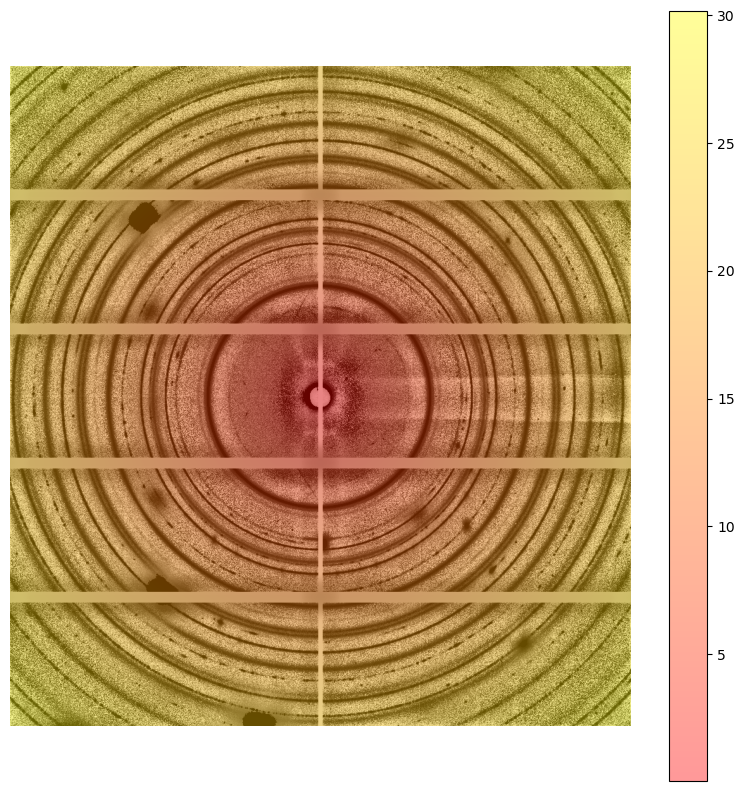

In [7]:
#Overlaying image and mask.TA

plt.figure(figsize=(10,10))
plt.imshow(normalized_example_im, cmap='binary', origin='lower',)  # Base image in grayscale
plt.imshow(mask.TA, cmap='autumn', alpha=0.4)  # Mask overlay with transparency
plt.colorbar()
plt.axis('off')
plt.show()

In [7]:
#Based on this result we'll redo the IOtth to respect these values in the above cell.

np.min(mask.TA), np.max(mask.TA)

(0.031165683642029762, 30.168989181518555)

In [8]:
#We'll be re-creating parts of "AutoSpotMask" without calling the C code. We're simply constructing the 2theta bins and seeing if every bin has some values in it

numchans = 200
LUtth = np.array(controls['IOtth'])
dtth = (LUtth[1]-LUtth[0])/numchans
TThs = np.linspace(LUtth[0], LUtth[1], numchans, False)


In [24]:
#Flatten mask
hist, _ = np.histogram(mask.TA.ravel(), bins = TThs)

In [34]:
lowest_count_indices = np.argsort(hist)[:10]
print(lowest_count_indices, hist[0])


[0 1 2 3 4 5 6 7 8 9] 49


# Troubleshooting 2theta map issues by running through code in mask.py in AIRXD-ML repo

In [3]:
npcosd = lambda x: np.cos(x*np.pi/180.)
npsind = lambda x: np.sin(x*np.pi/180.)
nptand = lambda x: np.tan(x*np.pi/180.)
npatand = lambda x: 180.*np.arctan(x)/np.pi
npatan2d = lambda y,x: 180.*np.arctan2(y,x)/np.pi

In [4]:
def peneCorr(tth, dep, dist):
    return dep*(1.-npcosd(tth))*dist**2/1000.

def makeMat(Angle, Axis):
    '''Make rotation matrix from Angle and Axis
    :param float Angle: in degrees
    :param int Axis: 0 for rotation about x, 1 for about y, etc.
    '''
    cs = npcosd(Angle)
    ss = npsind(Angle)
    M = np.array(([1.,0.,0.],[0.,cs,-ss],[0.,ss,cs]),dtype=np.float32)
    return np.roll(np.roll(M,Axis,axis=0),Axis,axis=1)

def Polarization(Pola, Tth, Azm=0.0):
    """   Calculate angle dependent x-ray polarization correction (not scaled correctly!)

    :param Pola: polarization coefficient e.g 1.0 fully polarized, 0.5 unpolarized
    :param Azm: azimuthal angle e.g. 0.0 in plane of polarization - can be numpy array
    :param Tth: 2-theta scattering angle - can be numpy array
        which (if either) of these is "right"?
    :return: (pola, dpdPola) - both 2-d arrays
        * pola = ((1-Pola)*npcosd(Azm)**2+Pola*npsind(Azm)**2)*npcosd(Tth)**2+ \
        (1-Pola)*npsind(Azm)**2+Pola*npcosd(Azm)**2
        * dpdPola: derivative needed for least squares

    """
    cazm = npcosd(Azm)**2
    sazm = npsind(Azm)**2
    pola = ((1.0-Pola)*cazm+Pola*sazm)*npcosd(Tth)**2+(1.0-Pola)*sazm+Pola*cazm
    dpdPola = -npsind(Tth)**2*(sazm-cazm)
    return pola,dpdPola



In [9]:
def GetTthAzmG2(x, y, data):
    '''Give 2-theta, azimuth & geometric corr. values for detector x,y position;
        calibration info in data - only used in integration - old version
    '''
    'Needs a doc string - checked OK for ellipses & hyperbola'
    #Angle detector normal makes with incident beam (-90 to 90 degrees)
    tilt = data['tilt']
    dist = data['distance']/npcosd(tilt)
    #Rotation matrix product
    #Check makeMat
    MN = -np.inner(makeMat(data['rotation'],2), makeMat(tilt,0))
    
    #Re-center x data based on detector center (from metadata)
    dx = x-data['center'][0]
    #Re-center y data based on detector center (from metadata)
    dy = y-data['center'][1]
    #Steps:
    #1. np.dstack stacks x, y and z coordinates "vertically"
    #2. The dot product applies transformation matrix to all coordinates
    #   We transpose x,y so we can multiply along third dimension in dot product
    
    #dz: z displacement from 0 (assumed planar position originally)
    dz = np.dot(np.dstack([dx.T,dy.T,np.zeros_like(dx.T)]),MN).T[2]

    #Subtraction is because we're going from a "tilted plane" to a "flat plane"
    #Our original tilted plane distance from the origin is dx**2 + dy**2
    #This "OG" tilted plane is actually the "hypotenuse" of the "true" xy distance
    #Hypotenuse = "true xy" + dz **2
    #=> "true xy" = Hypotenuse - dz**2
    xyZ = dx**2+dy**2-dz**2

    #dist = distance from sample to detector plane
    #Azimuthal angle is tth0
    tth0 = npatand(np.sqrt(xyZ)/(dist-dz))

    #Penetration correction for dz
    dzp = peneCorr(tth0, data['DetDepth'], dist)

    #Actual azimuthal correction for every position
    #2theta
    #dist-dz+dzp is corrected distance from sample to pixel
    #xyZ is distance from center of detector to pixel
    #npatan2d takes the sweeping angle from the vector (1,0), horizontal line
    #to the vector ending in (x,y)

    #This view is essentially looking at a cross section of sample and detector
    #2theta angle is deflection angle off of center of detector (no deflection)
    tth = npatan2d(np.sqrt(xyZ),dist-dz+dzp)
    #Azimuthal angle is rotation clockwise from (1,0) to dy/dx value in addition to azimuthal correction
    #Mod 360 in case rotation is greater than 360
    azm = (npatan2d(dy,dx)+data['azmthOff']+720.)%360.
    distsq = data['distance']**2

    #x0 is the displacement of the detector center from the sample center
    x0 = data['distance']*nptand(tilt)
    #x component of x0 correction
    x0x = x0*npcosd(data['rotation'])
    #y component of x0 correction
    x0y = x0*npsind(data['rotation'])

    #Sum of correction distances - geometric correction
    G = ((dx-x0x)**2+(dy-x0y)**2+distsq)/distsq
    return tth,azm,G


In [10]:
def Make2ThetaAzimuthMap(data, iLim, jLim):
    'Needs a doc string'
    pixelSize = data['pixelSize']
    scalex = pixelSize[0]/1000.
    scaley = pixelSize[1]/1000.
    tay,tax = np.mgrid[iLim[0]+0.5:iLim[1]+.5,jLim[0]+.5:jLim[1]+.5]
    tax = np.asfarray(tax*scalex,dtype=np.float32).flatten()
    tay = np.asfarray(tay*scaley,dtype=np.float32).flatten()
    print(tay)
    nI = iLim[1]-iLim[0]
    nJ = jLim[1]-jLim[0]
    TA = np.empty((4,nI,nJ))
    TA[:3] = np.array(GetTthAzmG2(np.reshape(tax,(nI,nJ)),np.reshape(tay,(nI,nJ)),data))
    TA[1] = np.where(TA[1]<0,TA[1]+360,TA[1])
    TA[3] = Polarization(data['PolaVal'][0],TA[0],TA[1]-90.)[0]
    return TA

In [6]:
poni_path = 'data/from_martin/Q_MINES_JuneJuly2023_RC08_RawData/Calibration/LaB6_calibration_225mm_30keV.poni'
controls = convert_to_imctrl(poni_path)
#Flip controls['center'] list from left to right to right to left
# controls['center'] = controls['center'][::-1]
shape = (1043, 981)

In [7]:
controls['center']

[84.2757267367562, 89.77996385601888]

In [11]:
res = Make2ThetaAzimuthMap(controls,(0,shape[0]),(0,shape[1]))

np.min(res[0]), np.max(res[0])

[8.6000e-02 8.6000e-02 8.6000e-02 ... 1.7931e+02 1.7931e+02 1.7931e+02]


(0.031165683642029762, 30.168989181518555)

Comparing ctrl file to known control file

In [216]:
from airxd_cnn.dataset import parse_imctrl

In [217]:
imctrl_file = 'data/battery1/TianyiBatteryControl.imctrl'
known_controls = parse_imctrl(imctrl_file)

In [219]:
known_res = Make2ThetaAzimuthMap(known_controls,(0,2880),(0,2880))
np.min(known_res[0]), np.max(known_res[0])

[7.50000e-02 7.50000e-02 7.50000e-02 ... 4.31925e+02 4.31925e+02
 4.31925e+02]


(0.012266278266906738, 37.817970275878906)

# Checking mask

We seemingly had no issues running the code on his masks. Let's check the result.

We'll run the pipeline on one or two test images just to make sure the general tuning is correct, before using the same parameters on the whole dataset.

In [3]:
from airxd_cnn.transforms import powder_normalize
import importlib
import pyFAI


In [4]:
poni_path = 'data/from_martin/Q_MINES_JuneJuly2023_RC08_RawData/Calibration/LaB6_calibration_225mm_30keV.poni'

#IMCTRL version of Poni_path for masking
controls = convert_to_imctrl(poni_path)
mask = MASK(controls = controls, shape = (1043, 981))

#PyFAI ponipath object for integration
ai = pyFAI.load(poni_path)
print(ai)

#Post-correction of min and max TA values for IOtth
# controls['IOtth'] = [65.2, 72.8]
# controls['rotation'] = controls['rotation'] + 90



Detector Detector	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 4.132000e-11 m
SampleDetDist= 2.127566e-01 m	PONI= 8.906751e-02, 8.634984e-02 m	rot1=0.009748  rot2=0.003348  rot3=-0.000000 rad
DirectBeamDist= 212.768 mm	Center: x=489.975, y=521.977 pix	Tilt= 0.591° tiltPlanRotation= 161.043° 𝛌= 0.413Å


In [5]:
#Test image
# example_im_dir = 'data/from_martin/Q_MINES_JuneJuly2023_RC09_RawData/'
example_im_dir = 'data/from_martin/Martin_Variable_Sapphire_Spots/'
example_im_files = glob(example_im_dir + '*.Tiff')
example_im_files.sort()
print(f'Directoy length: {len(example_im_files)}')


Directoy length: 24


In [29]:
idx = 8
im = iio.v2.volread(example_im_files[idx])
#Note to future self. Do NOT normalize the images before using median finder or else it simply won't work.
normalized_im = powder_normalize(im)

#Median filter
#Resetting the theta range to max instead of default ([0.8 17] approx)
controls['IOtth'] = [0.032, 30.15]
mask = MASK(controls, shape= im.shape)

im_to_mask = im
esdmul_mask = 1.5
# im_to_mask = normalized_im * 1e5
# esdmul_mask = 0.3

result = mask.AutoSpotMask(im_to_mask, esdmul_mask, numchans=300)


Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 1.5


In [ ]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
import mplcursors

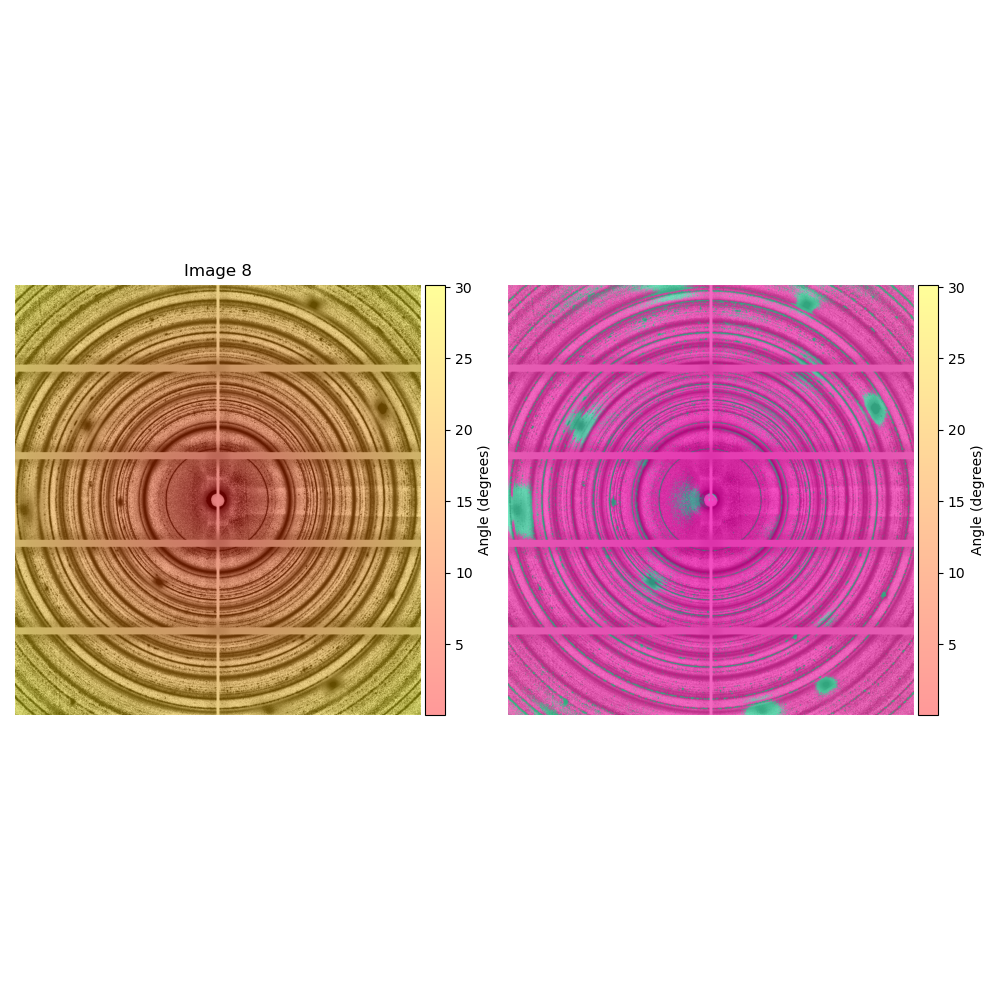

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
integration_mask = 1 - result

# Left subplot
im1 = ax[0].imshow(normalized_im, cmap='binary')
im2 = ax[0].imshow(mask.TA, cmap='autumn', alpha=0.4)
ax[0].set_title(f'Image {idx}')

# Right subplot
im3 = ax[1].imshow(normalized_im, cmap='binary', origin='lower')
im4 = ax[1].imshow(mask.TA, cmap='autumn', alpha=0.4)
im5 = ax[1].imshow(integration_mask, cmap='cool', alpha=0.5)

# Add colorbars with adjusted size
divider0 = make_axes_locatable(ax[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
cbar1 = fig.colorbar(im2, cax=cax0, label='Angle (degrees)')

divider1 = make_axes_locatable(ax[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
cbar2 = fig.colorbar(im4, cax=cax1, label='Angle (degrees)')

# Turn off axes
ax[0].axis('off')
ax[1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [46]:
def interactive_plot(im_to_plot, default_im,
                     mask_obj, mask,
                     plot_title):
    # Create figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    # Left subplot
    im1 = ax[0].imshow(im_to_plot, cmap='binary')
    im2 = ax[0].imshow(mask_obj.TA, cmap='autumn', alpha=0.4)
    ax[0].set_title(plot_title)

    # Right subplot
    im3 = ax[1].imshow(im_to_plot, cmap='binary', origin='lower')
    im4 = ax[1].imshow(mask_obj.TA, cmap='autumn', alpha=0.4)
    im5 = ax[1].imshow(np.ma.masked_where(mask == 0, mask), cmap='cool', alpha=0.5)
    # im5 = ax[1].imshow(np.ma.masked_where(result == 1, result), cmap='cool', alpha=0.5)

    # Add colorbars with adjusted size
    divider0 = make_axes_locatable(ax[0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    cbar1 = fig.colorbar(im2, cax=cax0, label='Angle (degrees)')

    divider1 = make_axes_locatable(ax[1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    cbar2 = fig.colorbar(im4, cax=cax1, label='Angle (degrees)')

    # Make plots interactive
    cursor1 = mplcursors.cursor(im2)
    @cursor1.connect("add")
    def on_add(sel):
        x, y = int(sel.target[0]), int(sel.target[1])
        angle = mask_obj.TA[y, x]
        z_val = default_im[y,x]
        sel.annotation.set_text(f'Angle: {angle:.2f}°\nx: {x}\ny: {y}\nraw: {z_val:.1f}\nmask: {mask[y,x]}')
        
    cursor2 = mplcursors.cursor(im4)
    @cursor2.connect("add")
    def on_add(sel):
        x, y = int(sel.target[0]), int(sel.target[1])
        angle = mask_obj.TA[y, x]
        z_val = default_im[y,x]
        sel.annotation.set_text(f'Angle: {angle:.2f}°\nx: {x}\ny: {y}\nraw: {z_val:.1f}\nmask: {mask[y,x]}')

    # Turn off axes
    ax[0].axis('off')
    ax[1].axis('off')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

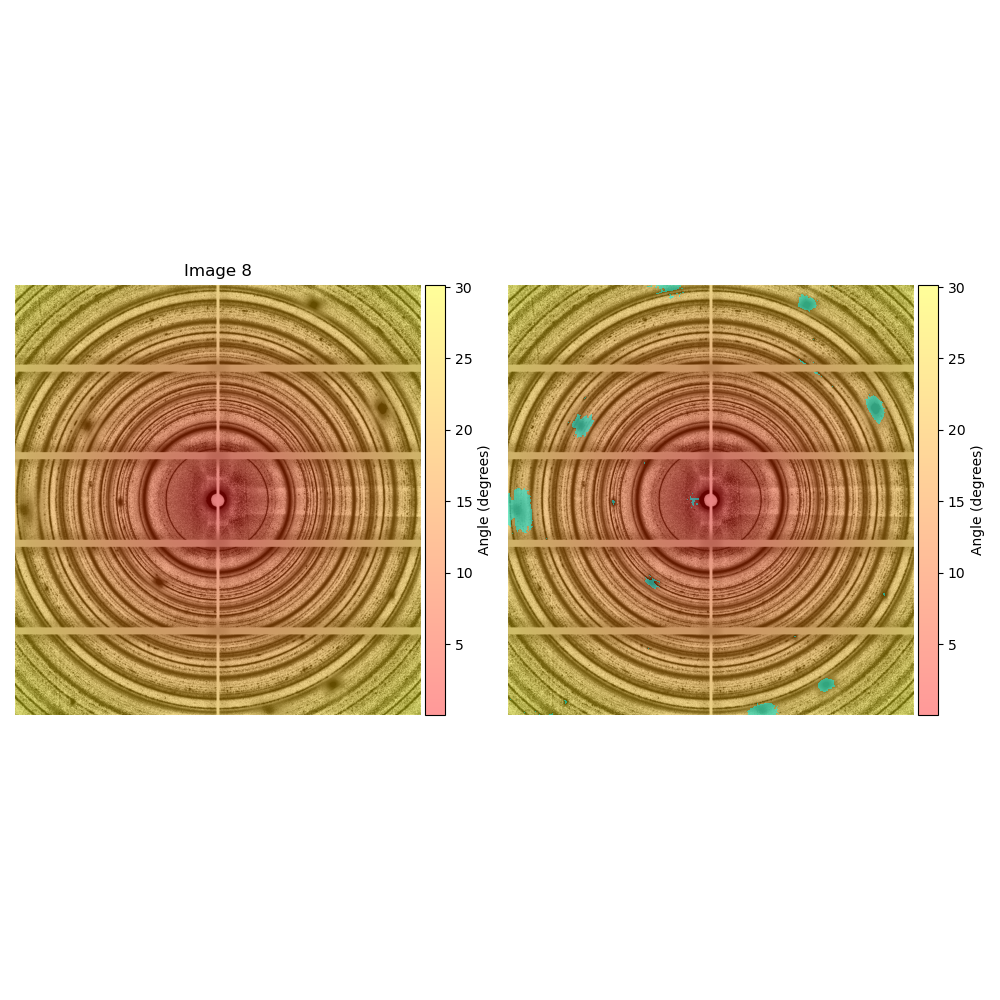

In [47]:
#Note: If interactivity doesn't work, change to Jupyter Widget renderer
#Interactable plot for troubleshooting
plot_name = 'Image ' + str(idx)

interactive_plot(normalized_im, im,
                 mask, result, plot_name)

In [52]:
#Test out PyFAI integration on im as well as im with mask
im[im < 0] = 0
integration_mask = 1 - result

normal_integration = ai.integrate1d_ng(im, 1000, unit = "2th_deg")
masked_integration = ai.integrate1d_ng(im, 1000, mask = integration_mask, unit = "2th_deg")

In [18]:
from pyFAI.gui import jupyter

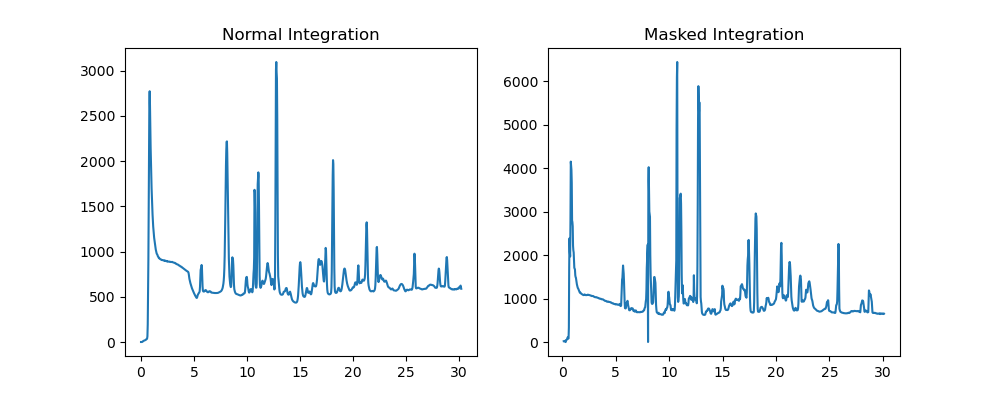

In [53]:
#Use matplotlib to plot normal_integration, but unpack using *normal_integration in argument

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(*normal_integration)
ax[0].set_title('Normal Integration')
ax[1].plot(*masked_integration)
ax[1].set_title('Masked Integration')
plt.show()

In [ ]:
normal_integration.intensity

# Gaussian convolutions

Note from 01/08/2025

Gaussian convolution is smearing out small islands of labelled noise which doesn't help the final image. May need to do an additional island masking step.

In [44]:
from scipy import ndimage
from scipy.ndimage import label
from skimage.measure import regionprops

In [45]:
def filter_connected_components_by_size(mask, min_size, max_size=None):
    """
    Filters connected components in the mask based on size.
    
    Parameters:
        mask (ndarray): Binary mask where spots are marked as 1, and the background is 0.
        min_size (int): Minimum number of pixels for a connected component to be kept.
        max_size (int, optional): Maximum number of pixels for a connected component to be kept. If None, no upper limit.
        
    Returns:
        filtered_mask (ndarray): Mask with only the connected components that meet the size criteria.
    """
    # Label each connected component in the binary mask
    labeled_mask, _ = label(mask)
    
    # Initialize an empty mask to hold the filtered components
    filtered_mask = np.zeros_like(mask)
    
    # Get properties of labeled regions
    regions = regionprops(labeled_mask)
    
    for region in regions:
        # Check the size of each region
        region_size = region.area
        if region_size >= min_size and (max_size is None or region_size <= max_size):
            # Add this region to the filtered mask
            filtered_mask[labeled_mask == region.label] = 1
    
    return filtered_mask

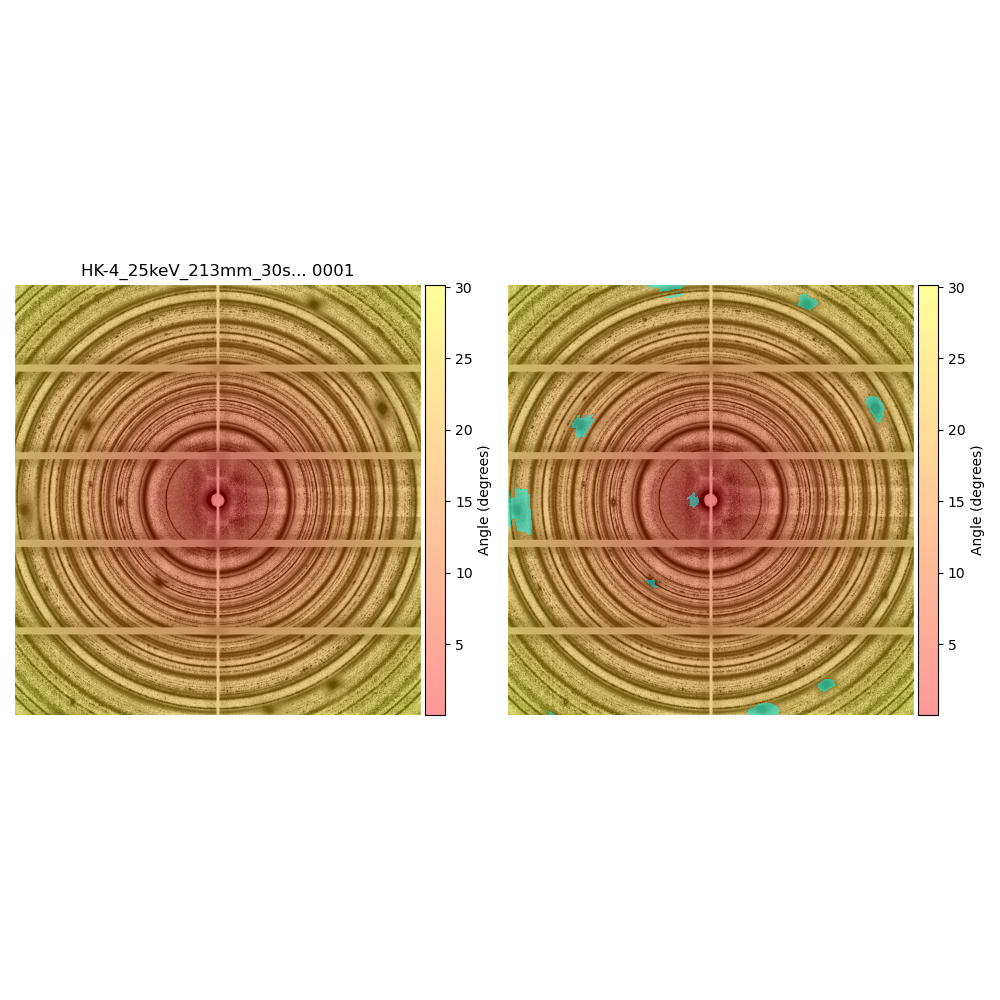

In [48]:
sigma = 2.5  # Adjust this value for different smoothing levels
threshold = 0.8
# Apply island masking first
# island_mask = filter_connected_components_by_size(result, min_size = 2)
smoothed_mask = ndimage.gaussian_filter(result, sigma=sigma)

thresholded_mask = (smoothed_mask > threshold).astype(float)

#Get last portion of file name from example_im_files[idx] separated by '/'
file_suffix = example_im_files[idx].split('/')[-1][:20] + '...' + example_im_files[idx].split('/')[-1][-10:-5]

# Visualize result
interactive_plot(normalized_im, im,
                 mask, thresholded_mask,
                 file_suffix)

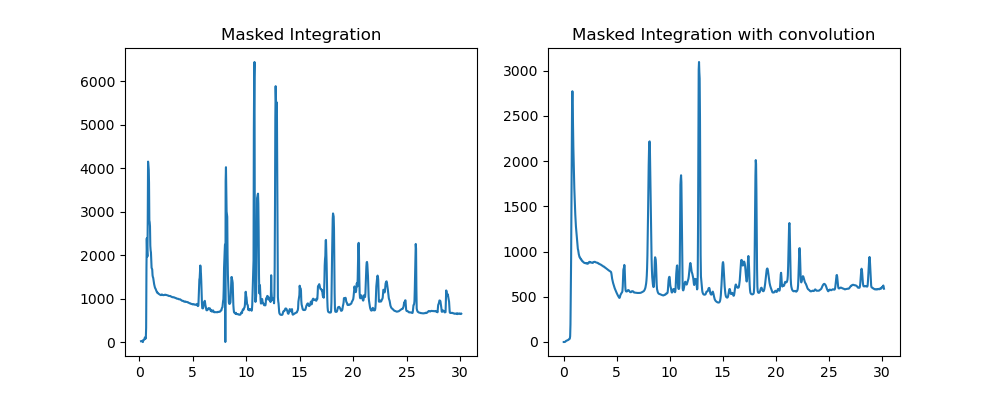

In [ ]:
#Now do PyFAI integration with convolution and w/o, and compare
#Test out PyFAI integration on im as well as im with mask
integration_mask = 1 - result

normal_integration = ai.integrate1d_ng(im, 1000, unit = "2th_deg")
masked_integration = ai.integrate1d_ng(im, 1000, mask = integration_mask, unit = "2th_deg")
masked_integration_conv = ai.integrate1d_ng(im, 1000, mask = thresholded_mask, unit = "2th_deg")

#Use matplotlib to plot normal_integration, but unpack using *normal_integration in argument

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(*masked_integration)
ax[0].set_title('Masked Integration')
ax[1].plot(*masked_integration_conv)
ax[1].set_title('Masked Integration with convolution')
plt.show()

In [58]:
normal_integration

(array([1.51077165e-02, 4.53231496e-02, 7.55385827e-02, 1.05754016e-01,
        1.35969449e-01, 1.66184882e-01, 1.96400315e-01, 2.26615748e-01,
        2.56831181e-01, 2.87046614e-01, 3.17262047e-01, 3.47477480e-01,
        3.77692914e-01, 4.07908347e-01, 4.38123780e-01, 4.68339213e-01,
        4.98554646e-01, 5.28770079e-01, 5.58985512e-01, 5.89200945e-01,
        6.19416378e-01, 6.49631811e-01, 6.79847244e-01, 7.10062677e-01,
        7.40278111e-01, 7.70493544e-01, 8.00708977e-01, 8.30924410e-01,
        8.61139843e-01, 8.91355276e-01, 9.21570709e-01, 9.51786142e-01,
        9.82001575e-01, 1.01221701e+00, 1.04243244e+00, 1.07264787e+00,
        1.10286331e+00, 1.13307874e+00, 1.16329417e+00, 1.19350961e+00,
        1.22372504e+00, 1.25394047e+00, 1.28415591e+00, 1.31437134e+00,
        1.34458677e+00, 1.37480221e+00, 1.40501764e+00, 1.43523307e+00,
        1.46544850e+00, 1.49566394e+00, 1.52587937e+00, 1.55609480e+00,
        1.58631024e+00, 1.61652567e+00, 1.64674110e+00, 1.676956

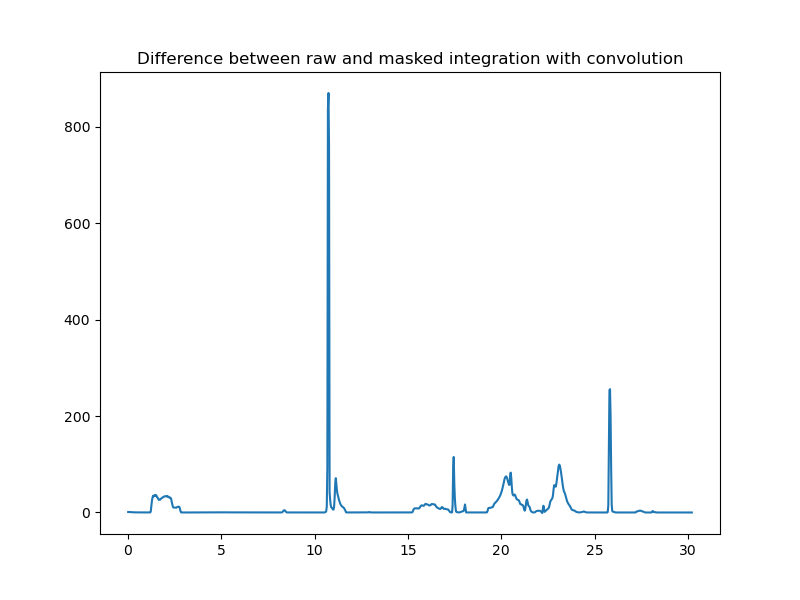

: 

In [ ]:
#Plot the difference between masked integration w/ convolution and raw

plt.figure(figsize=(8,6))
plt.plot(normal_integration[0], normal_integration[1] - masked_integration_conv[1])
plt.title('Difference between raw and masked integration with convolution')
plt.show()

Text(0.5, 1.0, 'Adjusted Image with artifacts removed')

<Figure size 1000x1000 with 0 Axes>

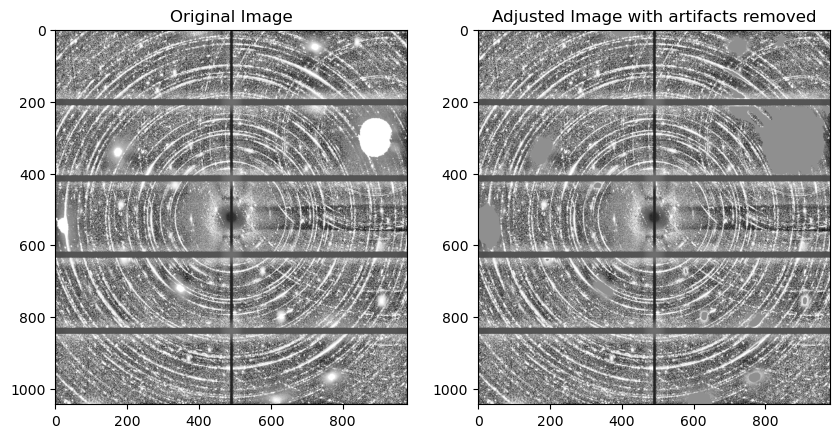

In [25]:
#Replace all the positive mask values with the median of im

med_im = np.median(normalized_im)
adjusted_im = normalized_im.copy()
adjusted_im[thresholded_mask == 1] = med_im



plt.figure(figsize=(10,10))
fig, ax = plt.subplots(1, 2, figsize=(10,10))
ax[0].imshow(normalized_im, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(adjusted_im, cmap='gray')
ax[1].set_title('Adjusted Image with artifacts removed')


# Pipeline to convert all other images    

In [12]:
import numpy as np
import imageio as iio
import matplotlib.pyplot as plt
import os
from glob import glob
from airxd_cnn.poni_parse import convert_to_imctrl
import airxd_old
from airxd.mask import MASK
from scipy import ndimage
from airxd_cnn.transforms import powder_normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pyFAI

In [13]:
#Controls pathing
control_path = 'data/from_martin/Q_MINES_JuneJuly2023_RC08_RawData/Calibration/LaB6_calibration_225mm_30keV.poni'
controls = convert_to_imctrl(control_path)
controls['IOtth'] = [0.032, 30.15]

#PyFai object for integration
ai = pyFAI.load(control_path)

#Median filter parameters
numChans = 300

#Convolution parameters
sigma = 2.5  # Adjust this value for different smoothing levels
threshold = 0.8

poni_path = 'data/from_martin/Q_MINES_JuneJuly2023_RC08_RawData/Calibration/LaB6_calibration_225mm_30keV.poni'

#PyFAI ponipath object for integration


In [21]:
base_dir = 'data/from_martin'

sub_dir = glob(base_dir + '/Martin_Variable_Sapphire_Spots')

for dir in sub_dir:
    im_list = glob(dir + '/*.Tiff')
    #Making directories
    if not os.path.exists(dir + '/masks'):
        os.mkdir(dir + '/masks')

    if not os.path.exists(os.path.join(dir,'mask_image_comparison')):
        os.mkdir(os.path.join(dir,'mask_image_comparison'))

    #Loop images
    for im_path in im_list:
        print(im_path)
        im = iio.v2.volread(im_path)
        norm_im = powder_normalize(im)

        #Median filter
        mask = MASK(controls, shape= im.shape)
        result = mask.AutoSpotMask(im, esdmul = 1.5, numchans=numChans)

        #Convolution masking
        smoothed_mask = ndimage.gaussian_filter(result, sigma=sigma)
        thresholded_mask = (smoothed_mask > threshold).astype(float)

        #Get save path
        im_name = im_path.split('/')[-1]
        # im_name = im_name.replace('.Tiff', '')
        save_path = os.path.join(dir, 'masks', im_name)

        #Save the result
        iio.imwrite(save_path, thresholded_mask)
        # Create figure with two subplots
        fig, ax = plt.subplots(1, 2, figsize=(10, 10))

        # Left subplot
        im1 = ax[0].imshow(norm_im, cmap='binary')
        im2 = ax[0].imshow(mask.TA, cmap='autumn', alpha=0.4)
        ax[0].set_title("Raw Image")
        ax[0].axis('off')

        # Right subplot
        im3 = ax[1].imshow(norm_im, cmap='binary', origin='lower')
        im4 = ax[1].imshow(mask.TA, cmap='autumn', alpha=0.4)
        im5 = ax[1].imshow(np.ma.masked_where(thresholded_mask == 0, thresholded_mask), cmap='cool', alpha=0.5)
        ax[1].set_title("Masked Image")
        ax[1].axis('off')

        # Add colorbars with adjusted size
        divider0 = make_axes_locatable(ax[0])
        cax0 = divider0.append_axes("right", size="5%", pad=0.05)
        cbar1 = fig.colorbar(im2, cax=cax0, label='Angle (degrees)')

        divider1 = make_axes_locatable(ax[1])
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        cbar2 = fig.colorbar(im4, cax=cax1, label='Angle (degrees)')

        # Adjust layout
        plt.tight_layout()

        # Save figure
        im_save_path = os.path.join(dir,'mask_image_comparison')
        fig_path = os.path.join(im_save_path, im_name + "_overlay.tiff")
        plt.savefig(fig_path, bbox_inches='tight', dpi=300)
        plt.close(fig)  # Close figure to free memory
        print(f"Saved: {fig_path}")

        # Now plot integrated intensities
        normal_integration = ai.integrate1d_ng(im, 1000, unit = "2th_deg")
        masked_integration_conv = ai.integrate1d_ng(im, 1000, mask = thresholded_mask, unit = "2th_deg")

        #Use matplotlib to plot normal_integration, but unpack using *normal_integration in argument

        fig, ax = plt.subplots(1, 2, figsize=(10,4))
        ax[0].plot(*normal_integration)
        ax[0].set_title('Raw Integration w/ calibration')
        ax[1].plot(*masked_integration_conv)
        ax[1].set_title('Masked Integration w/ calibration')


        # Save figure
        im_save_path = os.path.join(dir,'mask_image_comparison_integrated')
        fig_path = os.path.join(im_save_path, im_name + "_integrated.tiff")
        plt.savefig(fig_path, bbox_inches='tight', dpi=300)
        plt.close(fig)  # Close figure to free memory

        print(f"Saved: {fig_path}")




data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0031.Tiff
Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 1.5
Saved: data/from_martin/Martin_Variable_Sapphire_Spots/mask_image_comparison/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0031.Tiff_overlay.tiff
Saved: data/from_martin/Martin_Variable_Sapphire_Spots/mask_image_comparison_integrated/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0031.Tiff_integrated.tiff
data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0181.Tiff
Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 1.5
Saved: data/from_martin/Martin_Variable_Sapphire_Spots/mask_image_comparison/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0181.Tiff_overlay.tiff
Saved: data/from_martin/Martin_Variable_Sapphire_Spots/mask_image_comparison_integrated/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0181.Tiff_integrated.tiff
data/from_ma

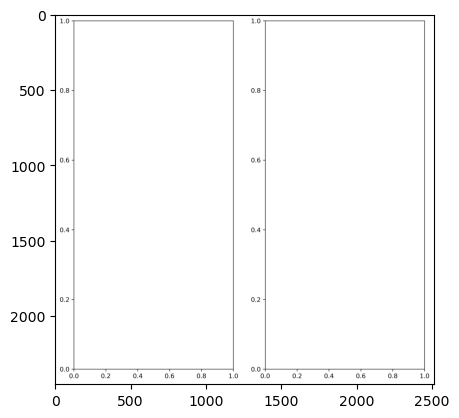

In [19]:
dir = 'data/from_martin/Martin_Variable_Sapphire_Spots/mask_image_comparison'

idx = 0

#Get list of all images in dir with glob
im_list = glob(os.path.join(dir, '*.tiff'))
im_list.sort()

#Import image w/ iio and plot it with matplotlib imshow
im = iio.imread(im_list[idx])
plt.imshow(im)
plt.show()



In [85]:
def view_im_and_mask(im_path, mask_path):
    im_name = im_path.split('/')[-1].replace('.Tiff', '')

    #Load image and mask
    im = iio.v2.volread(im_path)
    normalized_im = powder_normalize(im)
    mask = np.load(mask_path)

    # Visualize result
    fig, ax = plt.subplots(1, 2, figsize=(10,10))

    ax[0].imshow(normalized_im, cmap = 'gray')
    ax[0].set_title(f'Image {im_name[:20]}')
    ax[1].imshow(normalized_im, cmap='gray')
    ax[1].imshow(np.ma.masked_where(mask == 0, mask), cmap='autumn', alpha=0.4)
    # plt.colorbar()
    ax[1].set_title(f'Image {im_name[:20]}, threshold={threshold})')
    plt.show()

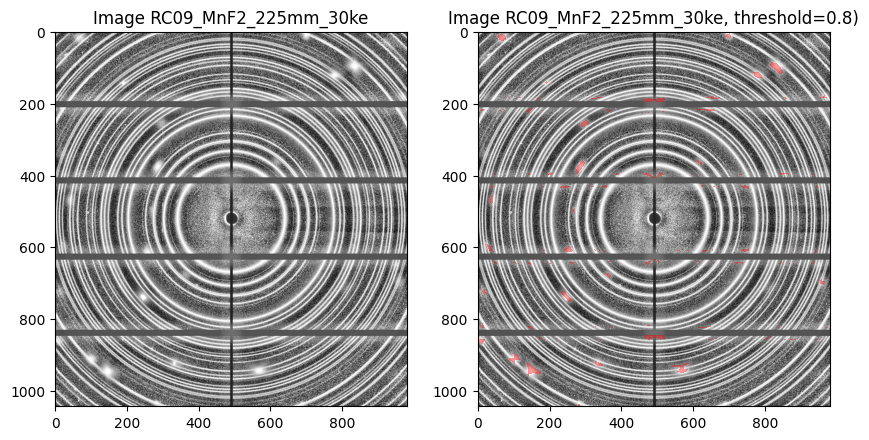

In [86]:
#Image info
sub_index = 1 #Sub directory index
image_index = 11 #Image index within sub directory

#Directory info
base_dir = 'data/from_martin'
sub_dir = glob(base_dir + '/*')
im_list = glob(sub_dir[sub_index] + '/*.Tiff')
im_list.sort()

#Getting paths of mask and image
im_path = im_list[image_index]
im_name = im_path.split('/')[-1].replace('.Tiff', '')
mask_path = os.path.join(sub_dir[sub_index], 'masks', im_name + '.npy')

view_im_and_mask(im_path, mask_path)

